# Data Preprocessing & EDA for Cross-Domain IDS

**Research:** Explainable Cross-Domain Intrusion Detection with Concept Drift

**Purpose:** Generate clean, harmonized datasets for cross-domain evaluation

**Inputs:**
- Raw CIC-IDS2017 CSV files (enterprise network traffic)
- Raw CICIoT2023 CSV files (IoT network traffic)

**Outputs:**
- `cicids2017_processed.csv` → Training dataset (source domain)
- `ciciot2023_processed.csv` → Testing dataset (target domain)

**Key Steps:**
1. Load and explore raw datasets
2. Fix column naming inconsistencies
3. Harmonize features across datasets
4. Standardize labels to unified taxonomy
5. Handle missing values and outliers
6. Save processed datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Configuration and Paths

**IMPORTANT:** Update these paths to match your local setup!

In [3]:
# UPDATE THESE PATHS FOR YOUR SYSTEM

# Input paths - raw data
PATH_2017_RAW = "/content/drive/MyDrive/hassnain/data/cicids2017"  # Directory containing all CIC-IDS2017 CSV files
PATH_IOT_RAW = "/content/drive/MyDrive/hassnain/data/ciciot2023"    # Directory containing all CICIoT2023 CSV files

# Output paths - processed data
OUTPUT_DIR = "/content/drive/MyDrive/hassnain/data/processed_data"
PATH_2017_PROCESSED = f"{OUTPUT_DIR}/cicids2017_processed.csv"
PATH_IOT_PROCESSED = f"{OUTPUT_DIR}/ciciot2023_processed.csv"

# Create output directory
Path(OUTPUT_DIR).mkdir(exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print(f"Configuration complete")

Output directory: /content/drive/MyDrive/hassnain/data/processed_data
Configuration complete


## 2. Load Raw Data

Load all CSV files from both datasets and combine them.

In [4]:
def load_dataset(data_dir, dataset_name):
    """
    Load all CSV files from a directory and combine them.
    """
    print(f"\n{'='*60}")
    print(f"Loading {dataset_name}")
    print(f"{'='*60}")

    data_path = Path(data_dir)
    csv_files = list(data_path.glob("**/*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    print(f"Found {len(csv_files)} CSV files")

    dfs = []
    for i, file in enumerate(csv_files, 1):
        try:
            df = pd.read_csv(file, low_memory=False)
            print(f"  [{i}/{len(csv_files)}] {file.name}: {len(df):,} rows, {len(df.columns)} columns")
            dfs.append(df)
        except Exception as e:
            print(f"  [ERROR] Failed to load {file.name}: {e}")

    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"\nCombined dataset: {len(combined_df):,} rows, {len(combined_df.columns)} columns")

    return combined_df

# Load both datasets
df_2017 = load_dataset(PATH_2017_RAW, "CIC-IDS2017")
df_iot = load_dataset(PATH_IOT_RAW, "CICIoT2023")


Loading CIC-IDS2017
Found 8 CSV files
  [1/8] Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows, 79 columns
  [2/8] Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows, 79 columns
  [3/8] Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows, 79 columns
  [4/8] Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows, 79 columns
  [5/8] Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows, 79 columns
  [6/8] Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows, 79 columns
  [7/8] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows, 79 columns
  [8/8] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows, 79 columns

Combined dataset: 2,830,743 rows, 79 columns

Loading CICIoT2023
Found 5 CSV files
  [1/5] Merged01.csv: 712,311 rows, 40 columns
  [2/5] Merged03.csv: 697,289 rows, 40 columns
  [3/5] Merged04.csv: 676,620 rows, 40 columns
  [4/5] Merged02.csv: 748,585 rows, 40 columns
  [5/5] Merged05.csv: 744,804 rows, 40 columns

Comb

## 3. Initial EDA - Dataset Overview

In [5]:
def display_dataset_info(df, dataset_name):
    """
    Display comprehensive dataset information.
    """
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Dataset Overview")
    print(f"{'='*60}")

    print(f"\nShape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\nData types:")
    print(df.dtypes.value_counts())

    print(f"\nMissing values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing': missing,
        'Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False).head(10))

    print(f"\nFirst few rows:")
    print(df.head(3))

    # Check for label column
    label_cols = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()]
    if label_cols:
        print(f"\nLabel distribution ({label_cols[0]}):")
        print(df[label_cols[0]].value_counts())

display_dataset_info(df_2017, "CIC-IDS2017")
display_dataset_info(df_iot, "CICIoT2023")


CIC-IDS2017 - Dataset Overview

Shape: (2830743, 79)
Memory usage: 1833.87 MB

Data types:
int64      54
float64    24
object      1
Name: count, dtype: int64

Missing values:
              Missing  Percentage
Flow Bytes/s     1358    0.047973

First few rows:
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   

    Fwd Packet Length M

## 4. Fix Column Naming Inconsistencies

**Critical Step:** CICIoT2023 uses different column names than CIC-IDS2017.

We need to standardize column names before harmonization.

In [6]:
# Define column mapping: CICIoT2023 → CIC-IDS2017 format
COLUMN_MAPPING = {
    # Basic flow features
    'flow_duration': 'Flow Duration',
    'Header_Length': 'Header Length',
    'Protocol Type': 'Protocol',
    'Duration': 'Flow Duration',

    # Packet counts
    'Tot Fwd Pkts': 'Total Fwd Packets',
    'Tot Bwd Pkts': 'Total Backward Packets',
    'TotLen Fwd Pkts': 'Total Length of Fwd Packets',
    'TotLen Bwd Pkts': 'Total Length of Bwd Packets',

    # Packet lengths
    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',
    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',

    # Flow IAT (Inter-Arrival Time)
    'Flow IAT Mean': 'Flow IAT Mean',
    'Flow IAT Std': 'Flow IAT Std',
    'Flow IAT Max': 'Flow IAT Max',
    'Flow IAT Min': 'Flow IAT Min',

    # Forward IAT
    'Fwd IAT Tot': 'Fwd IAT Total',
    'Fwd IAT Mean': 'Fwd IAT Mean',
    'Fwd IAT Std': 'Fwd IAT Std',
    'Fwd IAT Max': 'Fwd IAT Max',
    'Fwd IAT Min': 'Fwd IAT Min',

    # Backward IAT
    'Bwd IAT Tot': 'Bwd IAT Total',
    'Bwd IAT Mean': 'Bwd IAT Mean',
    'Bwd IAT Std': 'Bwd IAT Std',
    'Bwd IAT Max': 'Bwd IAT Max',
    'Bwd IAT Min': 'Bwd IAT Min',

    # Flags
    'Fwd PSH Flags': 'Fwd PSH Flags',
    'Bwd PSH Flags': 'Bwd PSH Flags',
    'Fwd URG Flags': 'Fwd URG Flags',
    'Bwd URG Flags': 'Bwd URG Flags',
    'FIN Flag Cnt': 'FIN Flag Count',
    'SYN Flag Cnt': 'SYN Flag Count',
    'RST Flag Cnt': 'RST Flag Count',
    'PSH Flag Cnt': 'PSH Flag Count',
    'ACK Flag Cnt': 'ACK Flag Count',
    'URG Flag Cnt': 'URG Flag Count',
    'CWE Flag Count': 'CWE Flag Count',
    'ECE Flag Cnt': 'ECE Flag Count',

    # Packet rates
    'Fwd Pkts/s': 'Fwd Packets/s',
    'Bwd Pkts/s': 'Bwd Packets/s',
    'Pkt Len Min': 'Min Packet Length',
    'Pkt Len Max': 'Max Packet Length',
    'Pkt Len Mean': 'Packet Length Mean',
    'Pkt Len Std': 'Packet Length Std',
    'Pkt Len Var': 'Packet Length Variance',

    # Additional features
    'Down/Up Ratio': 'Down/Up Ratio',
    'Pkt Size Avg': 'Average Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',
    'Init Fwd Win Byts': 'Init_Win_bytes_forward',
    'Init Bwd Win Byts': 'Init_Win_bytes_backward',
    'Fwd Act Data Pkts': 'act_data_pkt_fwd',
    'Fwd Seg Size Min': 'min_seg_size_forward',
    'Active Mean': 'Active Mean',
    'Active Std': 'Active Std',
    'Active Max': 'Active Max',
    'Active Min': 'Active Min',
    'Idle Mean': 'Idle Mean',
    'Idle Std': 'Idle Std',
    'Idle Max': 'Idle Max',
    'Idle Min': 'Idle Min',

    # Label
    'label': 'Label',
    'Label': 'Label',
    'Attack': 'Label'
}

def standardize_columns(df, dataset_name):
    """
    Standardize column names to CIC-IDS2017 format.
    """
    print(f"\n{'='*60}")
    print(f"Standardizing columns for {dataset_name}")
    print(f"{'='*60}")

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Apply mapping
    renamed_cols = {}
    for old_col, new_col in COLUMN_MAPPING.items():
        if old_col in df.columns:
            renamed_cols[old_col] = new_col

    if renamed_cols:
        df = df.rename(columns=renamed_cols)
        print(f"Renamed {len(renamed_cols)} columns")
    else:
        print(f"No columns needed renaming (already in standard format)")

    return df

# Standardize column names
df_2017 = standardize_columns(df_2017, "CIC-IDS2017")
df_iot = standardize_columns(df_iot, "CICIoT2023")

print(f"\nCIC-IDS2017 columns: {len(df_2017.columns)}")
print(f"CICIoT2023 columns: {len(df_iot.columns)}")


Standardizing columns for CIC-IDS2017
Renamed 27 columns

Standardizing columns for CICIoT2023
Renamed 3 columns

CIC-IDS2017 columns: 79
CICIoT2023 columns: 40


## 5. Domain-Invariant Feature Engineering

**Critical Understanding:** CIC-IDS2017 and CICIoT2023 have COMPLETELY DIFFERENT raw features!

- **CIC-IDS2017:** Flow-based (packet counts, IAT, flow duration)
- **CICIoT2023:** Protocol-based (protocol flags, HTTP/DNS indicators)

**Solution:** Engineer domain-invariant features that capture attack PATTERNS rather than absolute values:
- **Ratios** (forward/backward packet ratio)
- **Proportions** (forward packet proportion)
- **Normalized metrics** (coefficient of variation)
- **Binary indicators** (has PSH flag, has URG flag)

These engineered features transfer better across domains because they represent behavioral patterns.

In [7]:
def engineer_domain_invariant_features_2017(df):
    """
    Engineer domain-invariant features from CIC-IDS2017.
    Focus on ratios, proportions, and normalized metrics.
    """
    print("\nEngineering domain-invariant features for CIC-IDS2017...")

    df_eng = pd.DataFrame()

    # 1. Packet Size Ratios
    if 'Fwd Packet Length Mean' in df.columns and 'Bwd Packet Length Mean' in df.columns:
        df_eng['Fwd_Bwd_Packet_Ratio'] = df['Fwd Packet Length Mean'] / (df['Bwd Packet Length Mean'] + 1e-6)
        df_eng['Fwd_Bwd_Packet_Ratio'] = df_eng['Fwd_Bwd_Packet_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

    # 2. Flow Balance (Packet Direction Ratios)
    if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
        total_packets = df['Total Fwd Packets'] + df['Total Backward Packets'] + 1e-6
        df_eng['Fwd_Packet_Ratio'] = df['Total Fwd Packets'] / total_packets
        df_eng['Bwd_Packet_Ratio'] = df['Total Backward Packets'] / total_packets
        df_eng['Flow_Asymmetry'] = abs(df_eng['Fwd_Packet_Ratio'] - df_eng['Bwd_Packet_Ratio'])

    # 3. Byte Ratios
    if 'Total Length of Fwd Packets' in df.columns and 'Total Length of Bwd Packets' in df.columns:
        total_bytes = df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets'] + 1e-6
        df_eng['Fwd_Byte_Ratio'] = df['Total Length of Fwd Packets'] / total_bytes
        df_eng['Bwd_Byte_Ratio'] = df['Total Length of Bwd Packets'] / total_bytes

    # 4. Timing Patterns (Normalized)
    if 'Flow Duration' in df.columns:
        duration_sec = (df['Flow Duration'] / 1e6).replace([np.inf, -np.inf], 1e-6).fillna(1e-6)

        if 'Flow IAT Mean' in df.columns:
            df_eng['IAT_Duration_Ratio'] = (df['Flow IAT Mean'] / 1e6) / (duration_sec + 1e-6)
            df_eng['IAT_Duration_Ratio'] = df_eng['IAT_Duration_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

        if 'Total Fwd Packets' in df.columns:
            df_eng['Packets_Per_Second'] = (df['Total Fwd Packets'] + df.get('Total Backward Packets', 0)) / (duration_sec + 1e-6)
            df_eng['Packets_Per_Second'] = df_eng['Packets_Per_Second'].replace([np.inf, -np.inf], 0).fillna(0)

    # 5. Variability (Coefficient of Variation)
    if 'Fwd Packet Length Std' in df.columns and 'Fwd Packet Length Mean' in df.columns:
        df_eng['Fwd_Packet_CV'] = df['Fwd Packet Length Std'] / (df['Fwd Packet Length Mean'] + 1e-6)
        df_eng['Fwd_Packet_CV'] = df_eng['Fwd_Packet_CV'].replace([np.inf, -np.inf], 0).fillna(0)

    if 'Bwd Packet Length Std' in df.columns and 'Bwd Packet Length Mean' in df.columns:
        df_eng['Bwd_Packet_CV'] = df['Bwd Packet Length Std'] / (df['Bwd Packet Length Mean'] + 1e-6)
        df_eng['Bwd_Packet_CV'] = df_eng['Bwd_Packet_CV'].replace([np.inf, -np.inf], 0).fillna(0)

    # 6. Flag Indicators (Binary)
    flag_features = {
        'Has_FIN': 'FIN Flag Count',
        'Has_SYN': 'SYN Flag Count',
        'Has_RST': 'RST Flag Count',
        'Has_PSH': 'PSH Flag Count',
        'Has_ACK': 'ACK Flag Count',
        'Has_URG': 'URG Flag Count'
    }

    for new_name, old_name in flag_features.items():
        if old_name in df.columns:
            df_eng[new_name] = (df[old_name] > 0).astype(int)

    # 7. Statistical Features
    if 'Flow IAT Std' in df.columns and 'Flow IAT Mean' in df.columns:
        df_eng['IAT_CV'] = df['Flow IAT Std'] / (df['Flow IAT Mean'] + 1e-6)
        df_eng['IAT_CV'] = df_eng['IAT_CV'].replace([np.inf, -np.inf], 0).fillna(0)

    # 8. Protocol (if available)
    if 'Protocol' in df.columns:
        # One-hot encode common protocols
        df_eng['Protocol_TCP'] = (df['Protocol'] == 6).astype(int)
        df_eng['Protocol_UDP'] = (df['Protocol'] == 17).astype(int)
        df_eng['Protocol_ICMP'] = (df['Protocol'] == 1).astype(int)

    print(f"  Engineered {len(df_eng.columns)} domain-invariant features")

    return df_eng


def engineer_domain_invariant_features_iot(df):
    """
    Engineer domain-invariant features from CICIoT2023.
    Create similar feature concepts as CIC-IDS2017.
    """
    print("\nEngineering domain-invariant features for CICIoT2023...")

    df_eng = pd.DataFrame()

    # 1. Protocol Indicators (Binary)
    protocol_features = ['HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'ICMP']
    for proto in protocol_features:
        if proto in df.columns:
            df_eng[f'Has_{proto}'] = (df[proto] > 0).astype(int)

    # 2. Flag Indicators (Binary) - Match with 2017
    if 'fin_flag_number' in df.columns:
        df_eng['Has_FIN'] = (df['fin_flag_number'] > 0).astype(int)
    if 'syn_flag_number' in df.columns:
        df_eng['Has_SYN'] = (df['syn_flag_number'] > 0).astype(int)
    if 'rst_flag_number' in df.columns:
        df_eng['Has_RST'] = (df['rst_flag_number'] > 0).astype(int)
    if 'psh_flag_number' in df.columns:
        df_eng['Has_PSH'] = (df['psh_flag_number'] > 0).astype(int)
    if 'ack_flag_number' in df.columns:
        df_eng['Has_ACK'] = (df['ack_flag_number'] > 0).astype(int)

    # Statistical Features (Normalized)
    if 'Std' in df.columns and 'AVG' in df.columns:
        df_eng['Packet_CV'] = df['Std'] / (df['AVG'] + 1e-6)
        df_eng['Packet_CV'] = df_eng['Packet_CV'].replace([np.inf, -np.inf], 0).fillna(0)

    # 4. Rate Features
    if 'Rate' in df.columns:
        df_eng['Log_Rate'] = np.log1p(df['Rate'])

    if 'IAT' in df.columns:
        df_eng['Log_IAT'] = np.log1p(df['IAT'])

    # 5. Size Ratios
    if 'Min' in df.columns and 'Max' in df.columns:
        df_eng['Size_Range_Ratio'] = df['Min'] / (df['Max'] + 1e-6)
        df_eng['Size_Range_Ratio'] = df_eng['Size_Range_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

    # 6. Packet Statistics
    if 'Number' in df.columns and 'IAT' in df.columns:
        df_eng['Packets_Per_Second'] = df['Number'] / (df['IAT'] * df['Number'] + 1e-6)
        df_eng['Packets_Per_Second'] = df_eng['Packets_Per_Second'].replace([np.inf, -np.inf], 0).fillna(0)

    # 7. Protocol Type (Match with 2017)
    if 'Protocol' in df.columns:
        df_eng['Protocol_TCP'] = (df['Protocol'] == 6).astype(int)
        df_eng['Protocol_UDP'] = (df['Protocol'] == 17).astype(int)
        df_eng['Protocol_ICMP'] = (df['Protocol'] == 1).astype(int)

    print(f"  Engineered {len(df_eng.columns)} domain-invariant features")

    return df_eng


# Engineer features for both datasets
print(f"\n{'='*60}")
print(f"Domain-Invariant Feature Engineering")
print(f"{'='*60}")

df_2017_engineered = engineer_domain_invariant_features_2017(df_2017)
df_iot_engineered = engineer_domain_invariant_features_iot(df_iot)

# Find common engineered features
common_features = list(set(df_2017_engineered.columns) & set(df_iot_engineered.columns))

print(f"\n{'='*60}")
print(f"Common Engineered Features: {len(common_features)}")
print(f"{'='*60}")

if len(common_features) > 0:
    for i, feature in enumerate(sorted(common_features), 1):
        print(f"  {i:2d}. {feature}")

    # Create harmonized datasets with common features + label
    label_col_2017 = [col for col in df_2017.columns if 'label' in col.lower()][0]
    label_col_iot = [col for col in df_iot.columns if 'label' in col.lower()][0]

    df_2017_harmonized = df_2017_engineered[common_features].copy()
    df_2017_harmonized['Label'] = df_2017[label_col_2017]

    df_iot_harmonized = df_iot_engineered[common_features].copy()
    df_iot_harmonized['Label'] = df_iot[label_col_iot]

    print(f"\nHarmonization complete")
    print(f"  CIC-IDS2017: {df_2017_harmonized.shape}")
    print(f"  CICIoT2023: {df_iot_harmonized.shape}")
else:
    print("\nWARNING: No common engineered features found!")
    print("Using all features from each dataset separately.")

    label_col_2017 = [col for col in df_2017.columns if 'label' in col.lower()][0]
    label_col_iot = [col for col in df_iot.columns if 'label' in col.lower()][0]

    df_2017_harmonized = df_2017_engineered.copy()
    df_2017_harmonized['Label'] = df_2017[label_col_2017]

    df_iot_harmonized = df_iot_engineered.copy()
    df_iot_harmonized['Label'] = df_iot[label_col_iot]


Domain-Invariant Feature Engineering

Engineering domain-invariant features for CIC-IDS2017...
  Engineered 17 domain-invariant features

Engineering domain-invariant features for CICIoT2023...
  Engineered 23 domain-invariant features

Common Engineered Features: 6
   1. Has_ACK
   2. Has_FIN
   3. Has_PSH
   4. Has_RST
   5. Has_SYN
   6. Packets_Per_Second

Harmonization complete
  CIC-IDS2017: (2830743, 7)
  CICIoT2023: (3579609, 7)


## 6. Label Standardization - Unified Attack Taxonomy

Map all attacks to unified 6-category taxonomy:
1. **Normal** - Benign traffic
2. **DoS** - Denial of Service attacks (including DDoS)
3. **Probe** - Reconnaissance/scanning
4. **Exploit** - Exploitation attacks (malware, infiltration, etc.)
5. **Web** - Web-based attacks (XSS, SQL injection, etc.)
6. **Brute Force** - Password/dictionary attacks

In [8]:
# Define unified attack taxonomy mapping
ATTACK_TAXONOMY = {
    # Normal Traffic
    'BENIGN': 'Normal',
    'Benign': 'Normal',
    'Normal': 'Normal',

    # DoS/DDoS Attacks
    # CIC-IDS2017 DoS attacks
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DoS',
    'DoS': 'DoS',
    'Dos': 'DoS',
    'Heartbleed': 'DoS',

    # CICIoT2023 DoS/DDoS attacks
    'DDOS-ICMP_FLOOD': 'DoS',
    'DDOS-UDP_FLOOD': 'DoS',
    'DDOS-TCP_FLOOD': 'DoS',
    'DDOS-PSHACK_FLOOD': 'DoS',
    'DDOS-SYN_FLOOD': 'DoS',
    'DDOS-RSTFINFLOOD': 'DoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DoS',
    'DOS-UDP_FLOOD': 'DoS',
    'DOS-TCP_FLOOD': 'DoS',
    'DOS-SYN_FLOOD': 'DoS',
    'DOS-HTTP_FLOOD': 'DoS',
    'DDOS-HTTP_FLOOD': 'DoS',
    'DDOS-SLOWLORIS': 'DoS',
    'DDOS-ICMP_FRAGMENTATION': 'DoS',
    'DDOS-ACK_FRAGMENTATION': 'DoS',
    'DDOS-UDP_FRAGMENTATION': 'DoS',
    'MIRAI-GREETH_FLOOD': 'DoS',
    'MIRAI-UDPPLAIN': 'DoS',
    'MIRAI-GREIP_FLOOD': 'DoS',

    # Probe/Reconnaissance
    # CIC-IDS2017
    'PortScan': 'Probe',
    'Port Scan': 'Probe',
    'Portscan': 'Probe',
    'Scanning': 'Probe',
    'Recon': 'Probe',
    'Reconnaissance': 'Probe',

    # CICIoT2023
    'VULNERABILITYSCAN': 'Probe',
    'RECON-HOSTDISCOVERY': 'Probe',
    'RECON-OSSCAN': 'Probe',
    'RECON-PORTSCAN': 'Probe',
    'RECON-PINGSWEEP': 'Probe',

    # Exploitation
    # CIC-IDS2017
    'Infiltration': 'Exploit',
    'Bot': 'Exploit',
    'Botnet': 'Exploit',
    'Exploits': 'Exploit',
    'Backdoor': 'Exploit',
    'Ransomware': 'Exploit',
    'Malware': 'Exploit',

    # CICIoT2023
    'BACKDOOR_MALWARE': 'Exploit',
    'MITM-ARPSPOOFING': 'Exploit',
    'DNS_SPOOFING': 'Exploit',
    'UPLOADING_ATTACK': 'Exploit',

    # Web Attacks
    # CIC-IDS2017
    'Web Attack � Brute Force': 'Web',
    'Web Attack � XSS': 'Web',
    'Web Attack � Sql Injection': 'Web',
    'Web Attack': 'Web',
    'XSS': 'Web',
    'SQL Injection': 'Web',
    'Web': 'Web',

    # CICIoT2023
    'SQLINJECTION': 'Web',
    'COMMANDINJECTION': 'Web',
    'BROWSERHIJACKING': 'Web',

    # Brute Force
    # CIC-IDS2017
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Brute Force': 'Brute Force',
    'BruteForce': 'Brute Force',
    'Dictionary': 'Brute Force',
    'Password': 'Brute Force',

    # CICIoT2023
    'DICTIONARYBRUTEFORCE': 'Brute Force'
}

def map_to_unified_taxonomy(df, dataset_name):
    """
    Map attack labels to unified taxonomy.
    """
    print(f"\n{'='*60}")
    print(f"Mapping {dataset_name} to unified taxonomy")
    print(f"{'='*60}")

    print(f"\nOriginal label distribution:")
    print(df['Label'].value_counts())

    # Map labels
    df['Label_Unified'] = df['Label'].map(ATTACK_TAXONOMY)

    # Handle unmapped labels
    unmapped = df[df['Label_Unified'].isna()]['Label'].unique()
    if len(unmapped) > 0:
        print(f"\nUnmapped labels found: {unmapped}")
        print(f"Mapping them to 'Exploit' category")
        df['Label_Unified'].fillna('Exploit', inplace=True)

    print(f"\nUnified label distribution:")
    print(df['Label_Unified'].value_counts())

    # Create binary labels
    df['Label_Binary'] = df['Label_Unified'].apply(lambda x: 'Normal' if x == 'Normal' else 'Attack')

    print(f"\nBinary label distribution:")
    print(df['Label_Binary'].value_counts())

    return df

# Map labels for both datasets
df_2017_harmonized = map_to_unified_taxonomy(df_2017_harmonized, "CIC-IDS2017")
df_iot_harmonized = map_to_unified_taxonomy(df_iot_harmonized, "CICIoT2023")


Mapping CIC-IDS2017 to unified taxonomy

Original label distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Unified label distribution:
Label_Unified
Normal         2273097
DoS             380699
Probe           158930
Brute Force      13835
Web               2180
Exploit           2002
Name: count, dtype: int64

Binary label distribution:
Label_Binary
Normal    2273097
Attack     557646
Name: count, dtype: int64

Mapping CICIoT20

In [9]:
print("\n" + "="*70)
print("BALANCING CICIoT2023 DATASET")
print("="*70)

print("\nOriginal distribution:")
print(df_iot_harmonized['Label_Binary'].value_counts())
print(f"Attack ratio: {(df_iot_harmonized['Label_Binary']=='Attack').mean()*100:.2f}%")

# Get normal and attack samples
df_iot_normal = df_iot_harmonized[df_iot_harmonized['Label_Binary'] == 'Normal']
df_iot_attack = df_iot_harmonized[df_iot_harmonized['Label_Binary'] == 'Attack']

print(f"\nNormal samples: {len(df_iot_normal):,}")
print(f"Attack samples: {len(df_iot_attack):,}")

# Strategy 1: Keep all normals, undersample attacks to achieve ~30% attack ratio
# Target: 30% attack, 70% normal
# If we have 83,962 normals and want 70% normal, total = 83,962 / 0.7 = 119,946
# So attacks = 119,946 * 0.3 = 35,984

target_total = int(len(df_iot_normal) / 0.7)  # 119,946
target_attacks = int(target_total * 0.3)       # 35,984

print(f"\nTarget distribution:")
print(f"  Total samples: {target_total:,}")
print(f"  Normal: {len(df_iot_normal):,} (70%)")
print(f"  Attack: {target_attacks:,} (30%)")

# Undersample attacks randomly
df_iot_attack_sampled = df_iot_attack.sample(n=target_attacks, random_state=42)

# Combine
df_iot_balanced = pd.concat([df_iot_normal, df_iot_attack_sampled], ignore_index=True)

# Shuffle
df_iot_balanced = df_iot_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced distribution:")
print(df_iot_balanced['Label_Binary'].value_counts())
print(f"Attack ratio: {(df_iot_balanced['Label_Binary']=='Attack').mean()*100:.2f}%")

# Replace original with balanced version
df_iot_harmonized = df_iot_balanced


BALANCING CICIoT2023 DATASET

Original distribution:
Label_Binary
Attack    3495647
Normal      83962
Name: count, dtype: int64
Attack ratio: 97.65%

Normal samples: 83,962
Attack samples: 3,495,647

Target distribution:
  Total samples: 119,945
  Normal: 83,962 (70%)
  Attack: 35,983 (30%)

Balanced distribution:
Label_Binary
Normal    83962
Attack    35983
Name: count, dtype: int64
Attack ratio: 30.00%


## 7. Data Cleaning

Handle missing values, infinite values, and duplicates.

In [10]:
df_2017_harmonized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 9 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Has_ACK             int64  
 1   Has_FIN             int64  
 2   Has_SYN             int64  
 3   Has_RST             int64  
 4   Has_PSH             int64  
 5   Packets_Per_Second  float64
 6   Label               object 
 7   Label_Unified       object 
 8   Label_Binary        object 
dtypes: float64(1), int64(5), object(3)
memory usage: 194.4+ MB


In [11]:
df_iot_harmonized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119945 entries, 0 to 119944
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Has_ACK             119945 non-null  int64  
 1   Has_FIN             119945 non-null  int64  
 2   Has_SYN             119945 non-null  int64  
 3   Has_RST             119945 non-null  int64  
 4   Has_PSH             119945 non-null  int64  
 5   Packets_Per_Second  119945 non-null  float64
 6   Label               119945 non-null  object 
 7   Label_Unified       119945 non-null  object 
 8   Label_Binary        119945 non-null  object 
dtypes: float64(1), int64(5), object(3)
memory usage: 8.2+ MB


In [12]:
def clean_dataset(df, dataset_name):
    """
    Clean dataset: handle missing, infinite, and duplicate values.
    """
    print(f"\n{'='*60}")
    print(f"Cleaning {dataset_name}")
    print(f"{'='*60}")

    initial_rows = len(df)
    print(f"Initial rows: {initial_rows:,}")

    # 1. Handle infinite values
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['Label', 'Label_Unified', 'Label_Binary']]

    for col in numeric_cols:
        # Replace inf with NaN
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    inf_before = df[numeric_cols].isin([np.inf, -np.inf]).sum().sum()
    print(f"Replaced infinite values: {inf_before}")

    # 2. Handle missing values
    missing_before = df.isnull().sum().sum()

    # Fill missing values with 0 for numeric columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    missing_after = df.isnull().sum().sum()
    print(f"Missing values handled: {missing_before} → {missing_after}")

    # 3. Remove duplicates
    duplicates = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"Removed duplicates: {duplicates:,}")

    # 4. Remove any remaining rows with missing labels
    df = df.dropna(subset=['Label_Unified', 'Label_Binary'])

    final_rows = len(df)
    print(f"\nFinal rows: {final_rows:,} (removed {initial_rows - final_rows:,})")

    return df

# Clean both datasets
df_2017_clean = clean_dataset(df_2017_harmonized, "CIC-IDS2017")
df_iot_clean = clean_dataset(df_iot_harmonized, "CICIoT2023")


Cleaning CIC-IDS2017
Initial rows: 2,830,743
Replaced infinite values: 0
Missing values handled: 0 → 0
Removed duplicates: 1,559,966

Final rows: 1,270,777 (removed 1,559,966)

Cleaning CICIoT2023
Initial rows: 119,945
Replaced infinite values: 0
Missing values handled: 0 → 0
Removed duplicates: 10,636

Final rows: 109,309 (removed 10,636)


## 8. Feature Statistics and Distributions

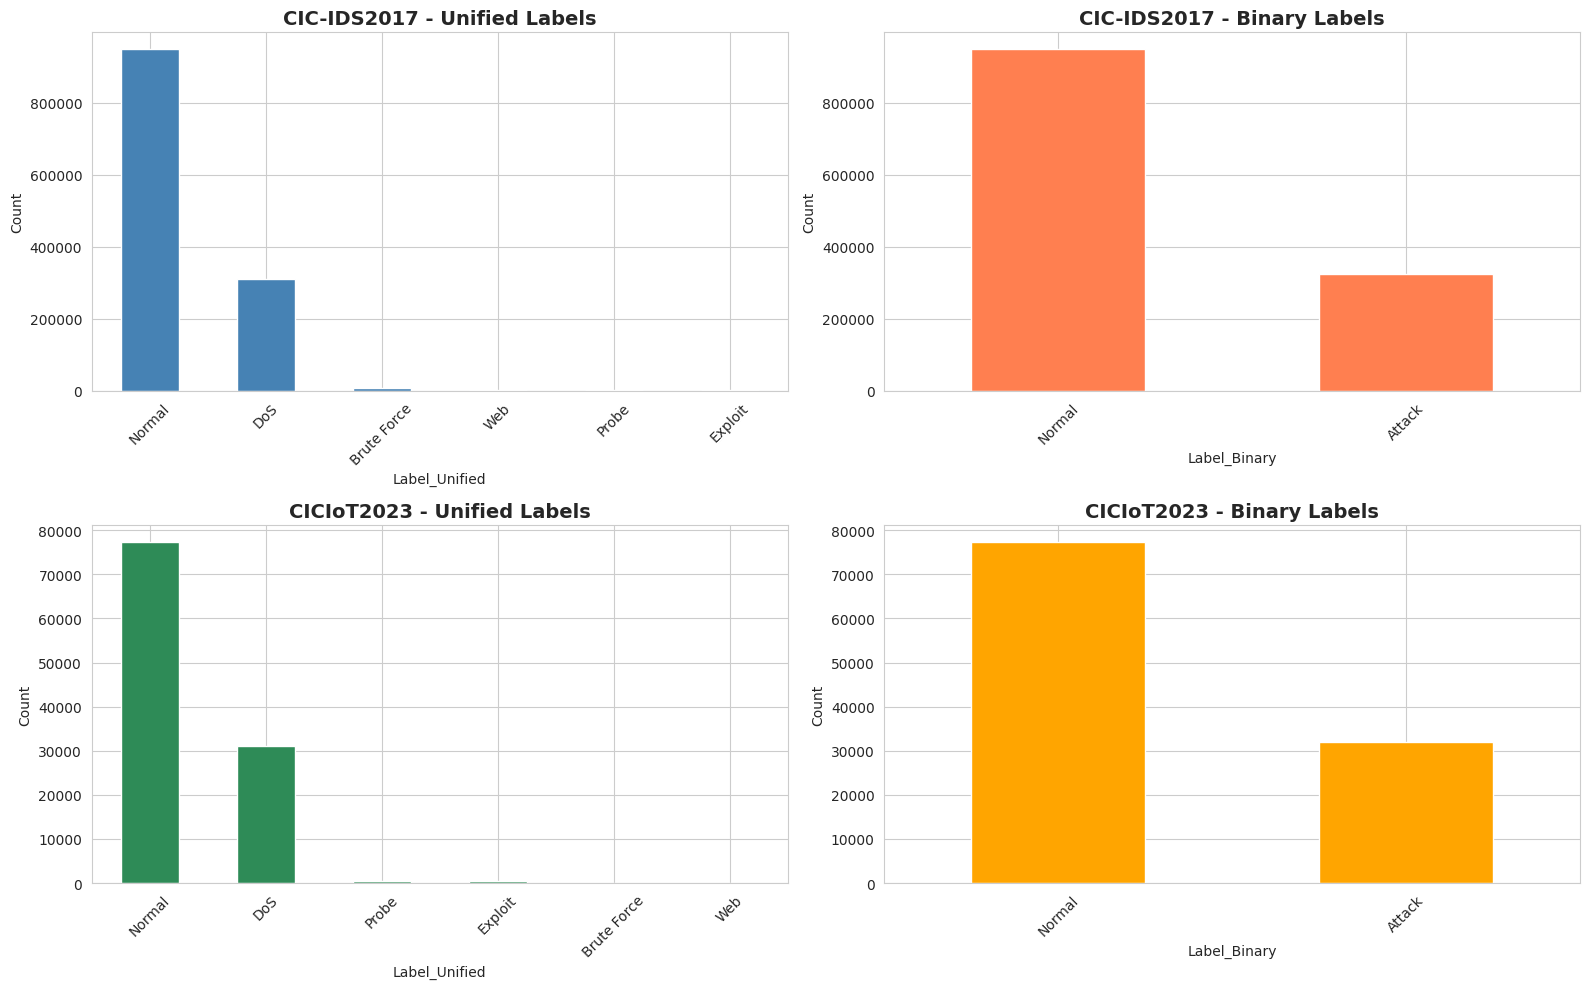


Label distribution plots saved to /content/drive/MyDrive/hassnain/data/processed_data/label_distributions.png


In [13]:
def plot_label_distributions(df_2017, df_iot):
    """
    Plot label distributions for both datasets.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # CIC-IDS2017 unified labels
    df_2017['Label_Unified'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('CIC-IDS2017 - Unified Labels', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # CIC-IDS2017 binary labels
    df_2017['Label_Binary'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('CIC-IDS2017 - Binary Labels', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # CICIoT2023 unified labels
    df_iot['Label_Unified'].value_counts().plot(kind='bar', ax=axes[1, 0], color='seagreen')
    axes[1, 0].set_title('CICIoT2023 - Unified Labels', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # CICIoT2023 binary labels
    df_iot['Label_Binary'].value_counts().plot(kind='bar', ax=axes[1, 1], color='orange')
    axes[1, 1].set_title('CICIoT2023 - Binary Labels', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/label_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nLabel distribution plots saved to {OUTPUT_DIR}/label_distributions.png")

plot_label_distributions(df_2017_clean, df_iot_clean)

In [14]:
def compute_feature_statistics(df_2017, df_iot):
    """
    Compute and compare feature statistics across datasets.
    """
    numeric_features = [col for col in df_2017.columns
                       if col not in ['Label', 'Label_Unified', 'Label_Binary']
                       and df_2017[col].dtype in [np.float64, np.int64]]

    print(f"\n{'='*60}")
    print(f"Feature Statistics Comparison")
    print(f"{'='*60}")

    stats_comparison = []

    for feature in numeric_features[:10]:  # Show first 10 features
        stats_2017 = df_2017[feature].describe()
        stats_iot = df_iot[feature].describe()

        stats_comparison.append({
            'Feature': feature,
            '2017_Mean': stats_2017['mean'],
            'IoT_Mean': stats_iot['mean'],
            '2017_Std': stats_2017['std'],
            'IoT_Std': stats_iot['std'],
            'Mean_Ratio': stats_2017['mean'] / (stats_iot['mean'] + 1e-10)
        })

    stats_df = pd.DataFrame(stats_comparison)
    print("\nTop features - Mean and Std comparison:")
    print(stats_df.to_string(index=False))

    return stats_df

stats_comparison = compute_feature_statistics(df_2017_clean, df_iot_clean)


Feature Statistics Comparison

Top features - Mean and Std comparison:
           Feature  2017_Mean    IoT_Mean     2017_Std      IoT_Std  Mean_Ratio
           Has_ACK   0.278544    0.778481     0.448283     0.415271    0.357804
           Has_FIN   0.053086    0.104209     0.224204     0.305533    0.509414
           Has_SYN   0.045746    0.170489     0.208934     0.376064    0.268322
           Has_RST   0.000537    0.047947     0.023177     0.213654    0.011210
           Has_PSH   0.482368    0.568526     0.499689     0.495284    0.848454
Packets_Per_Second 452.134930 8759.119795 13376.108840 21362.143246    0.051619


## 9. Save Processed Datasets

In [15]:
# Reorder columns: features first, then labels
feature_cols = [col for col in df_2017_clean.columns
               if col not in ['Label', 'Label_Unified', 'Label_Binary']]
label_cols = ['Label', 'Label_Unified', 'Label_Binary']
final_cols = feature_cols + label_cols

df_2017_final = df_2017_clean[final_cols]
df_iot_final = df_iot_clean[final_cols]

# Save to CSV
print(f"\n{'='*60}")
print(f"Saving Processed Datasets")
print(f"{'='*60}")

df_2017_final.to_csv(PATH_2017_PROCESSED, index=False)
print(f"CIC-IDS2017: {PATH_2017_PROCESSED}")
print(f"  Shape: {df_2017_final.shape}")
print(f"  Size: {df_2017_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df_iot_final.to_csv(PATH_IOT_PROCESSED, index=False)
print(f"\nCICIoT2023: {PATH_IOT_PROCESSED}")
print(f"  Shape: {df_iot_final.shape}")
print(f"  Size: {df_iot_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Saving Processed Datasets
CIC-IDS2017: /content/drive/MyDrive/hassnain/data/processed_data/cicids2017_processed.csv
  Shape: (1270777, 9)
  Size: 267.38 MB

CICIoT2023: /content/drive/MyDrive/hassnain/data/processed_data/ciciot2023_processed.csv
  Shape: (109309, 9)
  Size: 23.24 MB


## 10. Summary and Next Steps

In [16]:
print(f"\n{'='*70}")
print(f"PREPROCESSING SUMMARY")
print(f"{'='*70}")

print(f"\nDATASET STATISTICS:")
print(f"  CIC-IDS2017:")
print(f"    - Total samples: {len(df_2017_final):,}")
print(f"    - Features: {len(feature_cols)}")
print(f"    - Normal: {(df_2017_final['Label_Binary'] == 'Normal').sum():,}")
print(f"    - Attack: {(df_2017_final['Label_Binary'] == 'Attack').sum():,}")
print(f"    - Attack categories: {df_2017_final['Label_Unified'].nunique()}")

print(f"\n  CICIoT2023:")
print(f"    - Total samples: {len(df_iot_final):,}")
print(f"    - Features: {len(feature_cols)}")
print(f"    - Normal: {(df_iot_final['Label_Binary'] == 'Normal').sum():,}")
print(f"    - Attack: {(df_iot_final['Label_Binary'] == 'Attack').sum():,}")
print(f"    - Attack categories: {df_iot_final['Label_Unified'].nunique()}")

print(f"\nOUTPUT FILES:")
print(f"  1. {PATH_2017_PROCESSED}")
print(f"  2. {PATH_IOT_PROCESSED}")
print(f"  3. {OUTPUT_DIR}/label_distributions.png")


PREPROCESSING SUMMARY

DATASET STATISTICS:
  CIC-IDS2017:
    - Total samples: 1,270,777
    - Features: 6
    - Normal: 947,985
    - Attack: 322,792
    - Attack categories: 6

  CICIoT2023:
    - Total samples: 109,309
    - Features: 6
    - Normal: 77,356
    - Attack: 31,953
    - Attack categories: 6

OUTPUT FILES:
  1. /content/drive/MyDrive/hassnain/data/processed_data/cicids2017_processed.csv
  2. /content/drive/MyDrive/hassnain/data/processed_data/ciciot2023_processed.csv
  3. /content/drive/MyDrive/hassnain/data/processed_data/label_distributions.png
